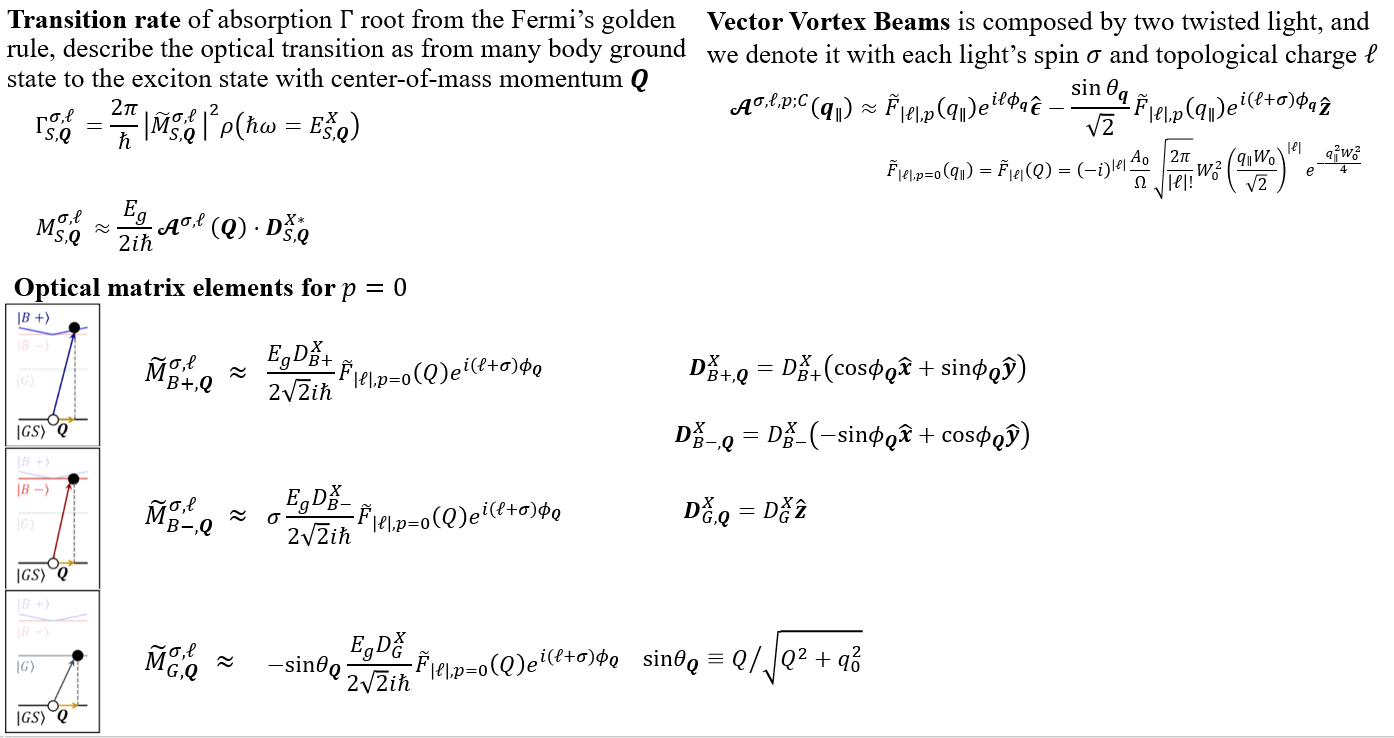

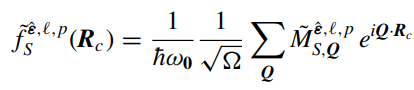

In [1]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
import matplotlib as mpl

from matplotlib.lines import Line2D
from matplotlib.colors import LightSource, LinearSegmentedColormap

In [66]:
#數值設定  
c = 299792458 #m/s
Eg = 1.7 #eV
D_B = 1.89 * 10**(-20) #um*C
D_G = 0.12 * 10**(-20) #um*C
a_0 = 1 #V*s
ZR = 11.81 #um
W = 1.5 #umz
Q_c = 8.6 #um^-1
q = 2*ZR/(W**2) #um-1
w = c*q*10**(-6)
hbar = 6.582119569 * 10**(-16) #eV*s
print("q=",q,"um-1$ \nw=",w,"s^-1 \nLamda=",2*np.pi/q,"um")

q= 10.497777777777777 um-1$ 
w= 3147.154603537778 s^-1 
Lamda= 0.5985252726991562 um


In [69]:
1.92/ (hbar*c)  #ev/(ev*s*m/s)=1/m

9730042.97577281

In [73]:
1.92/ (hbar*c) * np.power(0.1, 6)

9.730042975772813

In [3]:
def Factorial(n):
    f=1
    for i in range(1,int(n+1),1):
        f*=i 
    return f

def F(l,Q):
    F = (-complex(0,1))**(np.abs(l)) * 2*np.pi * a_0/W * 2**(-1-np.abs(l)/2) * np.sqrt(2*Factorial(p) / (Factorial(np.abs(l)+p))*np.pi) *np.exp(-Q**2*W**2/4) * W**2 * (Q*W)**(np.abs(l))
    return F

# def matrixelementr(ex, sigma, l, Q, phiQ):  Circular
    # if ex=="upperbright":
    #     matrix = 1/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # if ex=="lowerbright":
    #     matrix = sigma/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # if ex=="gray":
    #     matrix = -(Q/np.sqrt(Q**2+q**2))/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # return matrix

def matrixelement(ex, sigma, l, Q, phiQ):  # Linear in x
    if ex=="upperbright":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.cos(phiQ)
    if ex=="lowerbright":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  complex(0,1)*np.sin(phiQ)
    if ex=="gray":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*(l+sigma)*phiQ) *Q/np.sqrt(Q**2+q**2)
    return matrix

# def fun1(ex, sigma, l, Q, phiQ, R, phiR):
#     y = matrixelement(ex, sigma, l, Q, phiQ) * np.exp(complex(0,1)*Q*np.cos(phiQ)*R*np.cos(phiR)) * np.exp(complex(0,1)*Q*np.sin(phiQ)*R*np.sin(phiR))*Q
#     return y

def fun1(ex, sigma, l, Q, phiQ, R, phiR):
    y = matrixelement(ex, sigma, l, Q, phiQ) * np.exp(complex(0,1)*Q*np.cos(phiQ)*R*np.cos(phiR)) * np.exp(complex(0,1)*Q*np.sin(phiQ)*R*np.sin(phiR))*Q * np.exp(complex(0,1)*phiQ)
    return y

def fs1(ex, sigma, l, Q, R, phiR):
    max = 2*np.pi
    min = 0
    h=(max-min)/50
    sim = 0
    phiQ = min+h/2
    while (phiQ<=max):
        sim += h/6 * (fun1(ex, sigma, l, Q, phiQ-h/2, R, phiR)+4*fun1(ex, sigma, l, Q, phiQ, R, phiR)+fun1(ex, sigma, l, Q, phiQ+h/2, R, phiR))
        phiQ += h
    return sim
    
def fs2(ex, sigma, l, R, phiR):
    max = 4
    min = 0
    h=(max-min)/50
    sim = 0
    Q   = min+h/2
    while (Q<=max):
        sim += h/6 * (fs1(ex, sigma, l, Q-h/2, R, phiR)+4*fs1(ex, sigma, l, Q, R, phiR)+fs1(ex, sigma, l, Q+h/2, R, phiR))
        Q   += h
    return sim

In [4]:
# get colormap
ncolors = 1000
# color_array = plt.get_cmap('gist_gray')(np.linspace(0, 1, ncolors, endpoint=True))
# color_array = mpl.colormaps['seismic'].resampled(ncolors)
color_arrayBP = plt.get_cmap('gist_gray')(np.linspace(0, 1, ncolors, endpoint=True))
color_arrayBM = plt.get_cmap('gist_gray')(np.linspace(0, 1, ncolors, endpoint=True))
color_arrayB  = plt.get_cmap('gist_gray')(np.linspace(0, 1, ncolors, endpoint=True))
color_arrayG  = plt.get_cmap('gist_gray')(np.linspace(0, 1, ncolors, endpoint=True))

# change alpha values
ncolor = np.linspace(0,1,ncolors)
Yr= []
N = []
C = []
Yb= []
A = []
for i in range(len(ncolor)):
    Yr+= [round(np.sqrt( 5- (ncolor[i]-2)**2)-1, 10)]
    N += [np.sqrt( 1- (ncolor[i]-1)**2)-0]
    C += [-np.sqrt( 5- (ncolor[i]+1)**2)+2]
    Yb+= [(-np.sqrt( 5- (ncolor[i]+1)**2)+2) *0.5]
    A += [-0.015*np.log(ncolor[i]+0.02)+0.9]
    

# color_array[:,-1] = np.linspace(1.0,0.0,ncolors)
# color_array[:,-1] = A

color_arrayBP[:,0] = C
color_arrayBP[:,1] = C
color_arrayBP[:,2] = N
# color_arrayBP[:,-1] = A

color_arrayBM[:,0] = N
color_arrayBM[:,1] = C
color_arrayBM[:,2] = C
# color_arrayBM[:,-1] = A

color_arrayB[:,0] = Yr
color_arrayB[:,1] = N
color_arrayB[:,2] = Yb
# color_arrayB[:,-1] = A

color_arrayG[:,-1] = A
# create a colormap object
map_objectBP = LinearSegmentedColormap.from_list(name='colorbarBP',colors=color_arrayBP)
mpl.colormaps.register(cmap=map_objectBP)
map_objectBM = LinearSegmentedColormap.from_list(name='colorbarBM',colors=color_arrayBM)
mpl.colormaps.register(cmap=map_objectBM)
map_objectB  = LinearSegmentedColormap.from_list(name='colorbarB', colors=color_arrayB)
mpl.colormaps.register(cmap=map_objectB)
map_objectG  = LinearSegmentedColormap.from_list(name='colorbarG', colors=color_arrayG)
mpl.colormaps.register(cmap=map_objectG)

# register this new colormap with matplotlib
# plt.register_cmap(cmap=map_object)

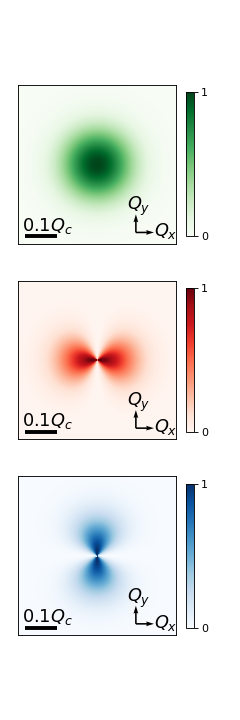

In [5]:
# betalpha = np.array([[0, 0], [np.pi, 0], [np.pi/2, 0], [np.pi/2, np.pi]])
sigma=1
l = 0
p=0
fig, ax = plt.subplots(3, 1, figsize=(3*1, 3*3), constrained_layout=False, dpi=80)

qx = np.linspace(-0.25*Q_c, 0.25*Q_c, 400)
qy = np.linspace(-0.25*Q_c, 0.25*Q_c, 400)
QX, QY = np.meshgrid(qx, qy)
phiQ = np.arctan2(QY, QX)
Q = np.sqrt(QX**2+QY**2)


for ex in range(3):
    ax[ex].cla()
    ax[ex].set_box_aspect(1)
    ax[ex].set_aspect('equal', adjustable='box')
    ax[ex].hlines(min(qy)+0.2, min(qx)+0.2, min(qx)+0.2+0.1*Q_c, color="k", linewidth=3.5, zorder=2)
    ax[ex].set_xlim(min(qx),max(qx))
    ax[ex].set_ylim(min(qy),max(qy))
    ax[ex].set_xticks([])
    ax[ex].set_yticks([])

    if ex==0:
        globals()['CS'+str(0)]=ax[0].contourf(QX, QY, np.abs(F(l,Q)*np.exp(complex(0,1)*l*phiQ))**2/np.max(np.abs(F(l,Q)*np.exp(complex(0,1)*l*phiQ))**2), 
                              vmin=0, vmax=1,levels=800, cmap='Greens')  
    if ex==1:
        ex = "upperbright"
        globals()['CS'+str(1)]=ax[1].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
                              vmin=0, vmax=1,levels=800, cmap='Reds')
    elif ex==2:
        ex = "lowerbright"
        globals()['CS'+str(2)]=ax[2].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
                              vmin=0, vmax=1,levels=800, cmap='Blues')
    # elif ex==3:
    #     ex = "gray"
    #     globals()['CS'+str(3)]=ax[3].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
    #                           vmin=0, vmax=1,levels=800, cmap='colorbarG')
      
    
for ex in range(3):
    ax[ex].quiver(max(qx)-1.1, min(qy)+0.3, 0, 0.8, scale=7, width=0.01, color='k', zorder=2)
    ax[ex].quiver(max(qx)-1.1, min(qy)+0.3, 0.8, 0, scale=7, width=0.01, color='k', zorder=2)
    ax[ex].text(max(qx)-1.35,  min(qy)+0.9,  '$Q_y$', fontsize=16, color='k')
    ax[ex].text(max(qx)-0.6,   min(qy)+0.2,  '$Q_x$', fontsize=16, color='k')
    ax[ex].text(min(qx)+0.1,   min(qy)+0.35, '$0.1 Q_c$', fontsize=16, color='k')
fig.colorbar(globals()['CS'+str(0)], shrink=0.78, format="{x:.0f}", ticks=np.linspace(0, 1, 2))
fig.colorbar(globals()['CS'+str(1)], shrink=0.78, format="{x:.0f}", ticks=np.linspace(0, 1, 2))
fig.colorbar(globals()['CS'+str(2)], shrink=0.78, format="{x:.0f}", ticks=np.linspace(0, 1, 2))

fig.subplots_adjust(left=0.075, bottom=0.1, right=0.9, top=0.9, wspace=0, hspace=0.06 )
# plt.tight_layout()
plt.show()

KeyboardInterrupt: 

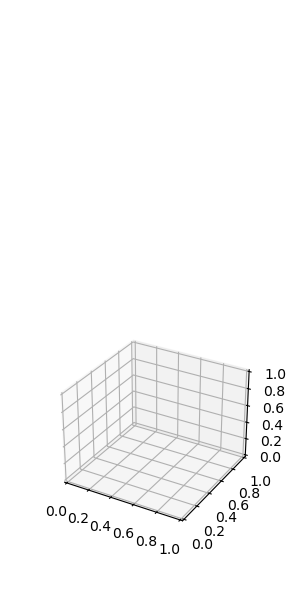

In [6]:
# betalpha = np.array([[0, 0], [np.pi, 0], [np.pi/2, 0], [np.pi/2, np.pi]])
sigma=1
l = -2

fig, ax = plt.subplots(2, 1, figsize=(3*1, 3*2), 
                       subplot_kw={'projection': '3d'}, 
                       constrained_layout=False, dpi=100)

x = np.linspace(-3*W, 3*W, 200)
y = np.linspace(-3*W, 3*W, 200)
X, Y = np.meshgrid(x, y)
phiR = np.arctan2(Y, X)
R = np.sqrt(X**2+Y**2)

def get_single_color_map(base_color):
    # This creates a gradient from black to your base color to white
    return LinearSegmentedColormap.from_list("custom", [base_color, base_color, base_color])
    
for ex in range(2):
    ax[ex].cla()
    ax[ex].set_xlim(min(x), max(x))
    ax[ex].set_ylim(min(y), max(y))
    ax[ex].set_zlim(0, 1)
    ax[ex].set_axis_off()
    ax[ex].set_xticks([])
    ax[ex].set_yticks([])
    ax[ex].set_zticks([])
    ax[ex].set_xlabel('x (um)')
    ax[ex].set_ylabel('y (um)')
    ax[ex].view_init(24, -118, 0) 
    # ax[ex].view_init(0, -90, 0)
    
    # Determine settings based on subplot index
    # if ex == 0:
    #     mode_name, color_base = "upperbright", 'pink'
    # else:
    #     mode_name, color_base = "lowerbright", 'green'
        
    # if ex == 0:
    #     mode_name, color_base = "upperbright", 'coral'
    # else:
    #     mode_name, color_base = "lowerbright", 'yellowgreen'
    
    if ex == 0:
        mode_name, color_base = "upperbright", 'peru'
    else:
        mode_name, color_base = "lowerbright", 'olivedrab'

    # Calculate normalized data
    data = np.abs(fs2(mode_name, sigma, l, R, phiR))**2
    maximum = np.max(np.abs(fs2(mode_name, sigma, 0, R, phiR))**2)
    z_norm = 0.35*(data / np.max(maximum))
    print(maximum)

    # Create the light source
    ls = LightSource(azdeg=315, altdeg=65)
    
    # Use a custom colormap based on your single color
    cmap = get_single_color_map(color_base)
    
    # Shade the surface (vert_exag controls how "sharp" the shadows look)
    rgb = ls.shade(z_norm, cmap=cmap, vert_exag=50, blend_mode='soft')

    # Plot using facecolors
    ax[ex].plot_surface(X, Y, z_norm, 
                        facecolors=rgb, 
                        linewidth=0, 
                        antialiased=False, 
                        shade=False,
                        zorder=2) # Manual shading is active

n=np.linspace(min(x), min(x)+W, 10)
m=np.linspace(min(y), min(y)+0.3*W, 10)
n, m = np.meshgrid(n, m)
ax[0].plot_surface(n, m, n*0+m*0+0.1, linewidth=0, color='k', zorder=0)
ax[1].plot_surface(n, m, n*0+m*0+0.1, linewidth=0, color='k', zorder=0)
# fig.subplots_adjust(left=0.075, bottom=0.1, right=0.9, top=0.9, wspace=0, hspace=0.06 )
plt.tight_layout()
plt.show()

In [61]:
def Factorial(n):
    f=1
    for i in range(1,int(n+1),1):
        f*=i 
    return f

def F(l,Q):
    F = (-complex(0,1))**(np.abs(l)) * 2*np.pi * a_0/W * 2**(-1-np.abs(l)/2) * np.sqrt(2*Factorial(p) / (Factorial(np.abs(l)+p))*np.pi) *np.exp(-Q**2*W**2/4) * W**2 * (Q*W)**(np.abs(l))
    return F

# def matrixelementr(ex, sigma, l, Q, phiQ):  Circular
    # if ex=="upperbright":
    #     matrix = 1/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # if ex=="lowerbright":
    #     matrix = sigma/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # if ex=="gray":
    #     matrix = -(Q/np.sqrt(Q**2+q**2))/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # return matrix

xpolarization = [1, 0]
ypolarization = [0, 1]
pluscircular = [1/np.sqrt(2), 1/np.sqrt(2)]
minuscircular = [1/np.sqrt(2), -1/np.sqrt(2)]
D_K = [1, 1]
D_Kprime = [1, -1]
    
def matrixelement(ex, sigma, l, Q, phiQ):  
    if sigma == 1:
        circular = pluscircular
    if sigma == -1:
        circular = minuscircular
        
    if ex=="circular_with_K":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.inner(circular, D_K)
        
    if ex=="circular_with_Kprime":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.inner(circular, D_Kprime)
        
    if ex=="x_with_K":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.inner(xpolarization, D_K)
        
    if ex=="x_with_Kprime":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.inner(xpolarization, D_Kprime)
    
    if ex=="y_with_K":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.inner(ypolarization, D_K)
        
    if ex=="y_with_Kprime":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.inner(ypolarization, D_Kprime)

    return matrix

# def fun1(ex, sigma, l, Q, phiQ, R, phiR):
#     y = matrixelement(ex, sigma, l, Q, phiQ) * np.exp(complex(0,1)*Q*np.cos(phiQ)*R*np.cos(phiR)) * np.exp(complex(0,1)*Q*np.sin(phiQ)*R*np.sin(phiR))*Q
#     return y

def fun1(ex, sigma, l, Q, phiQ, R, phiR):
    y = matrixelement(ex, sigma, l, Q, phiQ) * np.exp(complex(0,1)*Q*np.cos(phiQ)*R*np.cos(phiR)) * np.exp(complex(0,1)*Q*np.sin(phiQ)*R*np.sin(phiR)) * Q * np.exp(-complex(0,1)*phiQ)
    return y

def fs1(ex, sigma, l, Q, R, phiR):
    max = 2*np.pi
    min = 0
    h=(max-min)/50
    sim = 0
    phiQ = min+h/2
    while (phiQ<=max):
        sim += h/6 * (fun1(ex, sigma, l, Q, phiQ-h/2, R, phiR)+4*fun1(ex, sigma, l, Q, phiQ, R, phiR)+fun1(ex, sigma, l, Q, phiQ+h/2, R, phiR))
        phiQ += h
    return sim
    
def fs2(ex, sigma, l, R, phiR):
    max = 4
    min = 0
    h=(max-min)/50
    sim = 0
    Q   = min+h/2
    while (Q<=max):
        sim += h/6 * (fs1(ex, sigma, l, Q-h/2, R, phiR)+4*fs1(ex, sigma, l, Q, R, phiR)+fs1(ex, sigma, l, Q+h/2, R, phiR))
        Q   += h
    return sim

C:\Users\nycugpu\AppData\Local\Temp\ipykernel_3224\812120109.py:29: RuntimeWarning: invalid value encountered in divide
  globals()['CS'+str(1)]=ax[1].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2),


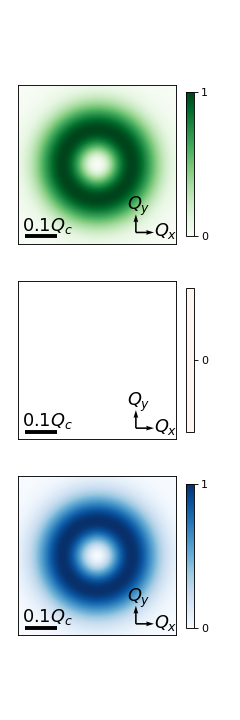

In [42]:
# betalpha = np.array([[0, 0], [np.pi, 0], [np.pi/2, 0], [np.pi/2, np.pi]])
sigma=-1
l = -1
p=0
fig, ax = plt.subplots(3, 1, figsize=(3*1, 3*3), constrained_layout=False, dpi=80)

qx = np.linspace(-0.25*Q_c, 0.25*Q_c, 400)
qy = np.linspace(-0.25*Q_c, 0.25*Q_c, 400)
QX, QY = np.meshgrid(qx, qy)
phiQ = np.arctan2(QY, QX)
Q = np.sqrt(QX**2+QY**2)


for ex in range(3):
    ax[ex].cla()
    ax[ex].set_box_aspect(1)
    ax[ex].set_aspect('equal', adjustable='box')
    ax[ex].hlines(min(qy)+0.2, min(qx)+0.2, min(qx)+0.2+0.1*Q_c, color="k", linewidth=3.5, zorder=2)
    ax[ex].set_xlim(min(qx),max(qx))
    ax[ex].set_ylim(min(qy),max(qy))
    ax[ex].set_xticks([])
    ax[ex].set_yticks([])

    if ex==0:
        globals()['CS'+str(0)]=ax[0].contourf(QX, QY, np.abs(F(l,Q)*np.exp(complex(0,1)*l*phiQ))**2/np.max(np.abs(F(l,Q)*np.exp(complex(0,1)*l*phiQ))**2), 
                              vmin=0, vmax=1,levels=800, cmap='Greens')  
    if ex==1:
        ex = "circular_with_K"
        globals()['CS'+str(1)]=ax[1].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
                              vmin=0, vmax=1,levels=800, cmap='Reds')
    elif ex==2:
        ex = "circular_with_Kprime"
        globals()['CS'+str(2)]=ax[2].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
                              vmin=0, vmax=1,levels=800, cmap='Blues')
    
    # if ex==1:
    #     ex = "x_with_K"
    #     globals()['CS'+str(1)]=ax[1].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
    #                           vmin=0, vmax=1,levels=800, cmap='Reds')
    # elif ex==2:
    #     ex = "x_with_Kprime"
    #     globals()['CS'+str(2)]=ax[2].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
    #                           vmin=0, vmax=1,levels=800, cmap='Blues')
        
    # if ex==1:
    #     ex = "y_with_K"
    #     globals()['CS'+str(1)]=ax[1].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
    #                           vmin=0, vmax=1,levels=800, cmap='Reds')
    # elif ex==2:
    #     ex = "y_with_Kprime"
    #     globals()['CS'+str(2)]=ax[2].contourf(QX, QY, np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2/np.max(np.abs(matrixelement(ex, sigma, l, Q, phiQ))**2), 
    #                           vmin=0, vmax=1,levels=800, cmap='Blues')


for ex in range(3):
    ax[ex].quiver(max(qx)-1.1, min(qy)+0.3, 0, 0.8, scale=7, width=0.01, color='k', zorder=2)
    ax[ex].quiver(max(qx)-1.1, min(qy)+0.3, 0.8, 0, scale=7, width=0.01, color='k', zorder=2)
    ax[ex].text(max(qx)-1.35,  min(qy)+0.9,  '$Q_y$', fontsize=16, color='k')
    ax[ex].text(max(qx)-0.6,   min(qy)+0.2,  '$Q_x$', fontsize=16, color='k')
    ax[ex].text(min(qx)+0.1,   min(qy)+0.35, '$0.1 Q_c$', fontsize=16, color='k')
fig.colorbar(globals()['CS'+str(0)], shrink=0.78, format="{x:.0f}", ticks=np.linspace(0, 1, 2))
fig.colorbar(globals()['CS'+str(1)], shrink=0.78, format="{x:.0f}", ticks=np.linspace(0, 1, 2))
fig.colorbar(globals()['CS'+str(2)], shrink=0.78, format="{x:.0f}", ticks=np.linspace(0, 1, 2))

fig.subplots_adjust(left=0.075, bottom=0.1, right=0.9, top=0.9, wspace=0, hspace=0.06 )
# plt.tight_layout()
plt.show()

3404.2278863741285


C:\Users\nycugpu\AppData\Local\Temp\ipykernel_3224\743871921.py:52: RuntimeWarning: invalid value encountered in divide
  z_norm = 0.35*(data / np.max(maximum))


0.0


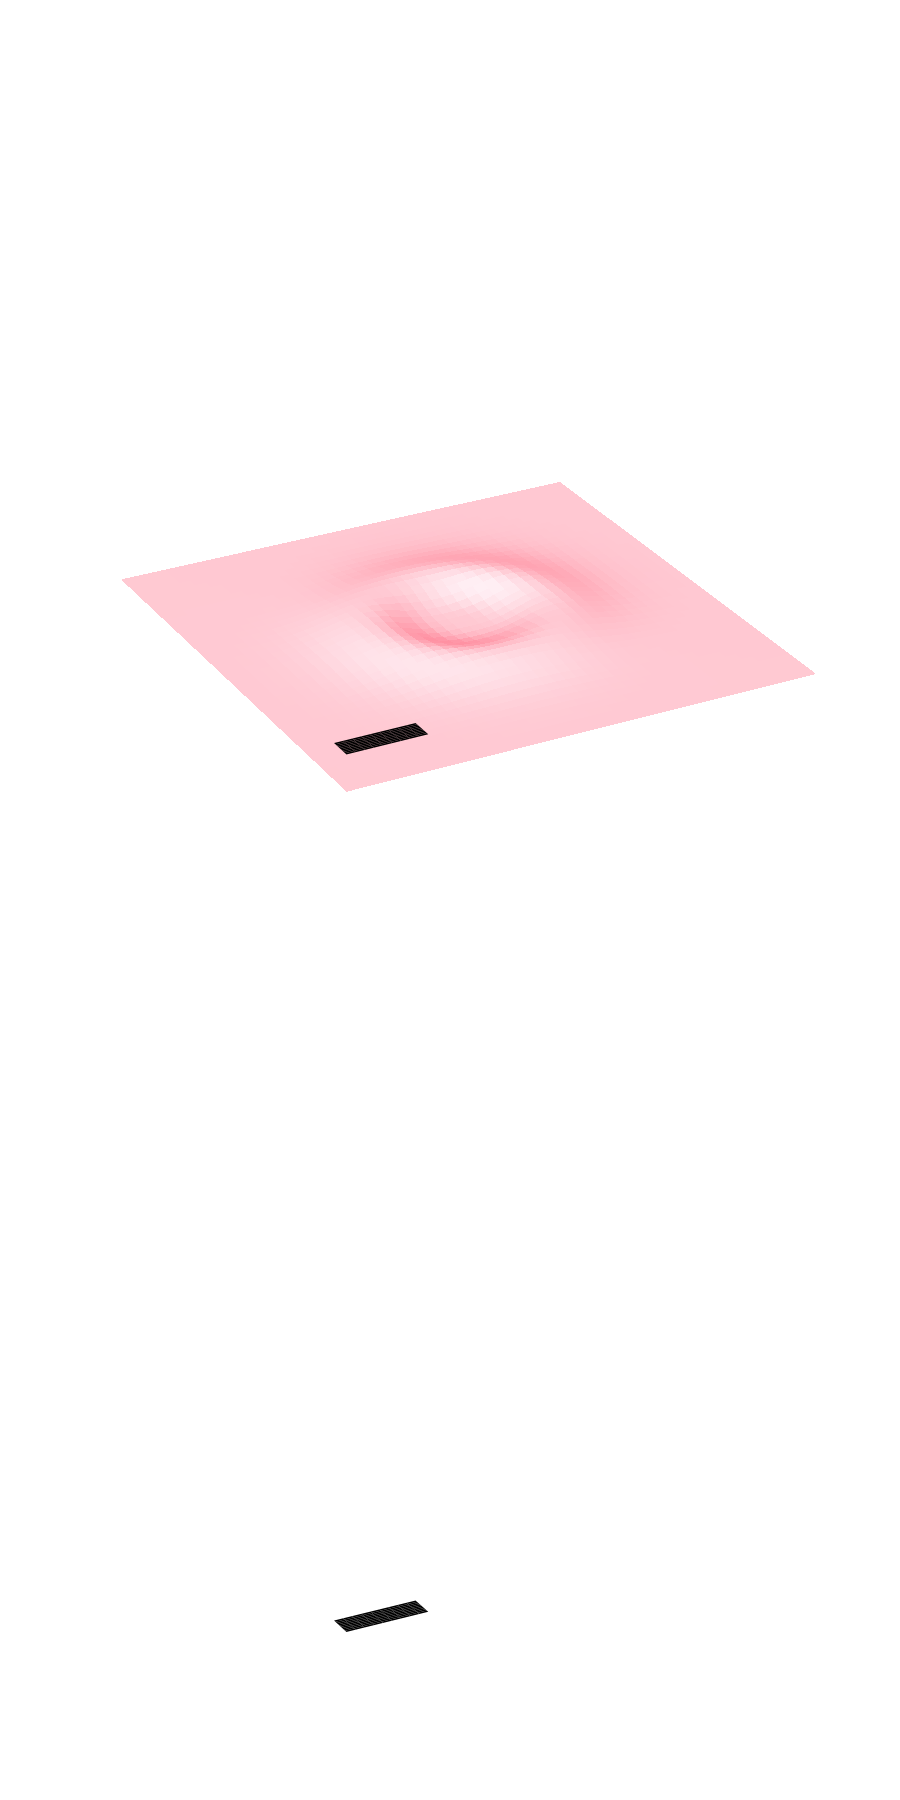

In [65]:
# betalpha = np.array([[0, 0], [np.pi, 0], [np.pi/2, 0], [np.pi/2, np.pi]])
sigma=1
l = -1

fig, ax = plt.subplots(2, 1, figsize=(3*1, 3*2), 
                       subplot_kw={'projection': '3d'}, 
                       constrained_layout=False, dpi=300)

x = np.linspace(-3*W, 3*W, 130)
y = np.linspace(-3*W, 3*W, 130)
X, Y = np.meshgrid(x, y)
phiR = np.arctan2(Y, X)
R = np.sqrt(X**2+Y**2)

def get_single_color_map(base_color):
    # This creates a gradient from black to your base color to white
    return LinearSegmentedColormap.from_list("custom", [base_color, base_color, base_color])
    
for ex in range(2):
    ax[ex].cla()
    ax[ex].set_xlim(min(x), max(x))
    ax[ex].set_ylim(min(y), max(y))
    ax[ex].set_zlim(0, 1)
    ax[ex].set_axis_off()
    ax[ex].set_xticks([])
    ax[ex].set_yticks([])
    ax[ex].set_zticks([])
    ax[ex].set_xlabel('x (um)')
    ax[ex].set_ylabel('y (um)')
    ax[ex].view_init(24, -118, 0) 
    # ax[ex].view_init(0, -90, 0)
    
    #Determine settings based on subplot index
    if ex == 0:
        mode_name, color_base = "circular_with_K", 'pink'
    else:
        mode_name, color_base = "circular_with_Kprime", 'green'
        
    # if ex == 0:
    #     mode_name, color_base = "x_with_K", 'coral'
    # else:
    #     mode_name, color_base = "x_with_Kprime", 'yellowgreen'
    
    # if ex == 0:
    #     mode_name, color_base = "y_with_K", 'peru'
    # else:
    #     mode_name, color_base = "y_with_Kprime", 'olivedrab'

    # Calculate normalized data
    data = np.abs(fs2(mode_name, sigma, l, R, phiR))**2
    maximum = np.max(np.abs(fs2(mode_name, sigma, 1, R, phiR))**2)
    z_norm = 0.35*(data / np.max(maximum))
    print(maximum)

    # Create the light source
    ls = LightSource(azdeg=315, altdeg=65)
    
    # Use a custom colormap based on your single color
    cmap = get_single_color_map(color_base)
    
    # Shade the surface (vert_exag controls how "sharp" the shadows look)
    rgb = ls.shade(z_norm, cmap=cmap, vert_exag=50, blend_mode='soft')

    # Plot using facecolors
    ax[ex].plot_surface(X, Y, z_norm, 
                        facecolors=rgb, 
                        linewidth=0, 
                        antialiased=False, 
                        shade=False,
                        zorder=2) # Manual shading is active

n=np.linspace(min(x), min(x)+W, 10)
m=np.linspace(min(y), min(y)+0.3*W, 10)
n, m = np.meshgrid(n, m)
ax[0].plot_surface(n, m, n*0+m*0+0.1, linewidth=0, color='k', zorder=0)
ax[1].plot_surface(n, m, n*0+m*0+0.1, linewidth=0, color='k', zorder=0)
# fig.subplots_adjust(left=0.075, bottom=0.1, right=0.9, top=0.9, wspace=0, hspace=0.06 )
plt.tight_layout()
plt.show()

In [344]:
def Factorial(n):
    f=1
    for i in range(1,int(n+1),1):
        f*=i 
    return f

def F(l,Q):
    F = (-complex(0,1))**(np.abs(l)) * 2*np.pi * a_0/W * 2**(-1-np.abs(l)/2) * np.sqrt(2*Factorial(p) / (Factorial(np.abs(l)+p))*np.pi) *np.exp(-Q**2*W**2/4) * W**2 * (Q*W)**(np.abs(l))
    return F

# def matrixelementr(ex, sigma, l, Q, phiQ):  Circular
    # if ex=="upperbright":
    #     matrix = 1/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # if ex=="lowerbright":
    #     matrix = sigma/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # if ex=="gray":
    #     matrix = -(Q/np.sqrt(Q**2+q**2))/complex(0,1)*F(l,Q)*np.exp(complex(0,1)*(sigma+l)*phiQ)
    # return matrix

def matrixelement(ex, sigma, l, Q, phiQ):  # Linear in x
    if ex=="upperbright":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.cos(phiQ)
    if ex=="lowerbright":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  complex(0,1)*np.sin(phiQ)
    if ex=="gray":
        matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*(l+sigma)*phiQ) *Q/np.sqrt(Q**2+q**2)
    return matrix

# def fun1(ex, sigma, l, Q, phiQ, R, phiR):
#     y = matrixelement(ex, sigma, l, Q, phiQ) * np.exp(complex(0,1)*Q*np.cos(phiQ)*R*np.cos(phiR)) * np.exp(complex(0,1)*Q*np.sin(phiQ)*R*np.sin(phiR))*Q
#     return y

def fun1(ex, sigma, l, Q, phiQ, R, phiR, alpha):
    y = matrixelement(ex, sigma, l, Q, phiQ) * np.exp(complex(0,1)*Q*np.cos(phiQ)*R*np.cos(phiR)) * np.exp(complex(0,1)*Q*np.sin(phiQ)*R*np.sin(phiR))*Q * np.exp(-complex(0,1)*alpha*phiQ)
    return y

def fs1(ex, sigma, l, Q, R, phiR, alpha):
    max = 2*np.pi
    min = 0
    h=(max-min)/50
    sim = 0
    phiQ = min+h/2
    while (phiQ<=max):
        sim += h/6 * (fun1(ex, sigma, l, Q, phiQ-h/2, R, phiR, alpha)+4*fun1(ex, sigma, l, Q, phiQ, R, phiR, alpha)+fun1(ex, sigma, l, Q, phiQ+h/2, R, phiR, alpha))
        phiQ += h
    return sim
    
def fs2(ex, sigma, l, R, phiR, alpha):
    max = 4
    min = 0
    h=(max-min)/50
    sim = 0
    Q   = min+h/2
    while (Q<=max):
        sim += h/6 * (fs1(ex, sigma, l, Q-h/2, R, phiR, alpha)+4*fs1(ex, sigma, l, Q, R, phiR, alpha)+fs1(ex, sigma, l, Q+h/2, R, phiR, alpha))
        Q   += h
    return sim

TypeError: fs2() takes 5 positional arguments but 6 were given

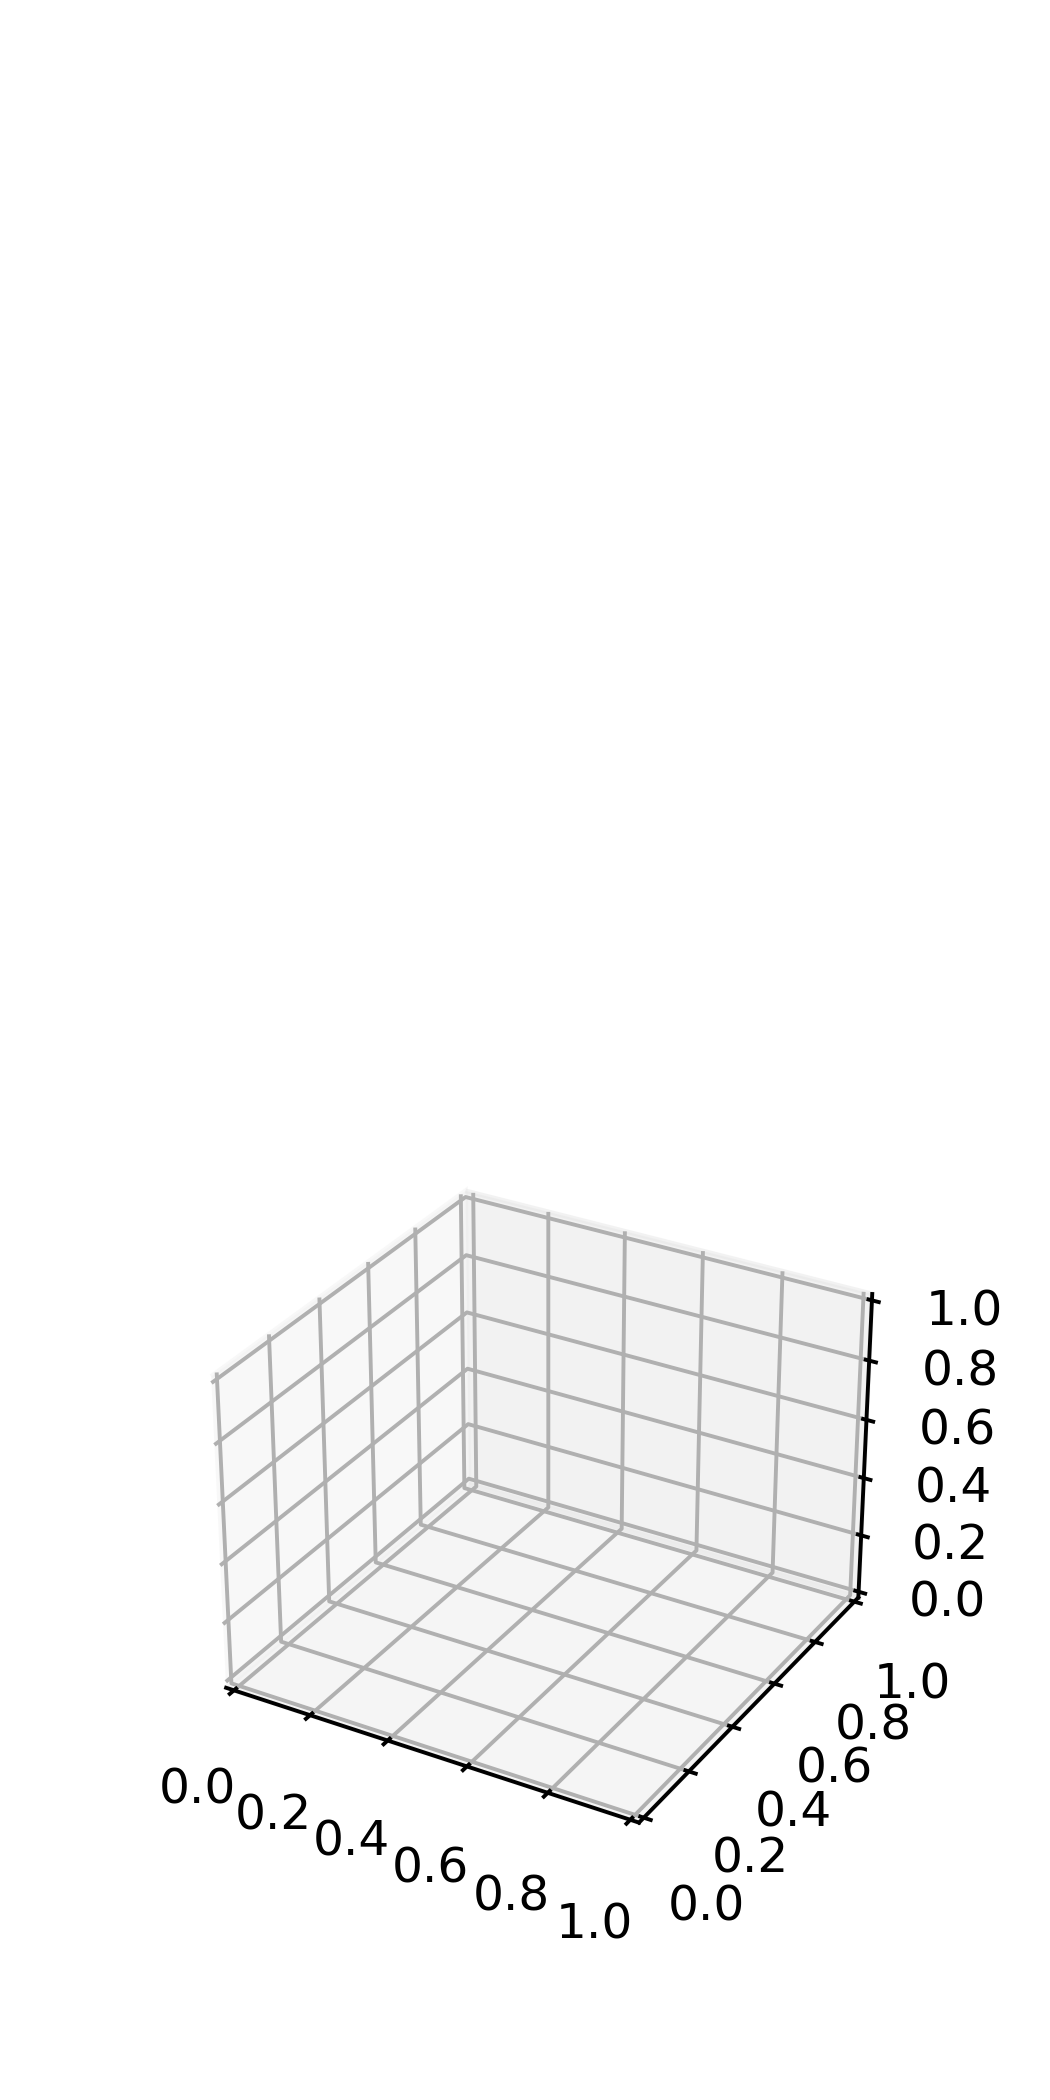

In [47]:
# betalpha = np.array([[0, 0], [np.pi, 0], [np.pi/2, 0], [np.pi/2, np.pi]])
sigma=1
l = 0

fig, ax = plt.subplots(2, 1, figsize=(3*1, 3*2), 
                       subplot_kw={'projection': '3d'}, 
                       constrained_layout=False, dpi=350)

x = np.linspace(-3*W, 3*W, 25)
y = np.linspace(-3*W, 3*W, 25)
X, Y = np.meshgrid(x, y)
phiR = np.arctan2(Y, X)
R = np.sqrt(X**2+Y**2)

def get_single_color_map(base_color):
    # This creates a gradient from black to your base color to white
    return LinearSegmentedColormap.from_list("custom", [base_color, base_color, base_color])
    
for ex in range(2):
    ax[ex].cla()
    ax[ex].set_xlim(min(x), max(x))
    ax[ex].set_ylim(min(y), max(y))
    ax[ex].set_zlim(0, 1)
    ax[ex].set_axis_off()
    ax[ex].set_xticks([])
    ax[ex].set_yticks([])
    ax[ex].set_zticks([])
    ax[ex].set_xlabel('x (um)')
    ax[ex].set_ylabel('y (um)')
    ax[ex].view_init(24, -118, 0) 
    # ax[ex].view_init(0, -90, 0)
    
    # Determine settings based on subplot index
    # if ex == 0:
    #     mode_name, color_base = "upperbright", 'pink'
    # else:
    #     mode_name, color_base = "lowerbright", 'green'
        
    if ex == 0:
        mode_name, color_base = "upperbright", 'coral'
    else:
        mode_name, color_base = "lowerbright", 'yellowgreen'
    
    # if ex == 0:
    #     mode_name, color_base = "upperbright", 'peru'
    # else:
    #     mode_name, color_base = "lowerbright", 'olivedrab'

    # Calculate normalized data
    data = np.abs(fs2(mode_name, sigma, l, R, phiR, 1))**2
    maximum = np.max(np.abs(fs2(mode_name, sigma, 0, R, phiR, 0))**2)
    z_norm = 0.35*(data / np.max(maximum))
    print(maximum)

    # Create the light source
    ls = LightSource(azdeg=315, altdeg=65)
    
    # Use a custom colormap based on your single color
    cmap = get_single_color_map(color_base)
    
    # Shade the surface (vert_exag controls how "sharp" the shadows look)
    rgb = ls.shade(z_norm, cmap=cmap, vert_exag=50, blend_mode='soft')

    # Plot using facecolors
    ax[ex].plot_surface(X, Y, z_norm, 
                        facecolors=rgb, 
                        linewidth=0, 
                        antialiased=False, 
                        shade=False,
                        zorder=2) # Manual shading is active

n=np.linspace(min(x), min(x)+W, 10)
m=np.linspace(min(y), min(y)+0.3*W, 10)
n, m = np.meshgrid(n, m)
ax[0].plot_surface(n, m, n*0+m*0+0.1, linewidth=0, color='k', zorder=0)
ax[1].plot_surface(n, m, n*0+m*0+0.1, linewidth=0, color='k', zorder=0)
# fig.subplots_adjust(left=0.075, bottom=0.1, right=0.9, top=0.9, wspace=0, hspace=0.06 )
plt.tight_layout()
plt.show()

In [393]:
# def Factorial(n):
#     f=1
#     for i in range(1,int(n+1),1):
#         f*=i 
#     return f

# def F(l,Q):
#     F = (-complex(0,1))**(np.abs(l)) * 2*np.pi * a_0/W * 2**(-1-np.abs(l)/2) * np.sqrt(2*Factorial(p) / (Factorial(np.abs(l)+p))*np.pi) *np.exp(-Q**2*W**2/4) * W**2 * (Q*W)**(np.abs(l))
#     return F

# def matrixelement(ex, sigma, l, Q, phiQ):  # Linear in x
#     if ex=="upperbright":
#         matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  np.cos(phiQ)
#     if ex=="lowerbright":
#         matrix = 1/(2*complex(0,1))*F(l,Q)*np.exp(complex(0,1)*l*phiQ)  *  complex(0,1)*np.sin(phiQ)
#     return matrix

# def fun1(ex, sigma, l, Q, phiQ, R, phiR, alpha):
#     y = matrixelement(ex, sigma, l, Q, phiQ) * np.exp(complex(0,1)*Q*np.cos(phiQ)*R*np.cos(phiR)) * np.exp(complex(0,1)*Q*np.sin(phiQ)*R*np.sin(phiR)) * np.exp(-complex(0,1)*alpha*phiQ) * Q
#     return y

# def int_phiQ_1(ex, sigma, l, Q, R, phiR, alpha):
#     max = 2*np.pi
#     min = 0
#     h=(max-min)/50
#     sim = 0
#     phiQ = min+h/2
#     while (phiQ<=max):
#         sim += h/6 * (fun1(ex, sigma, l, Q, phiQ-h/2, R, phiR, alpha)+4*fun1(ex, sigma, l, Q, phiQ, R, phiR, alpha)+fun1(ex, sigma, l, Q, phiQ+h/2, R, phiR, alpha))
#         phiQ += h
#     return sim
    
# def int_Q_1(ex, sigma, l, R, phiR, alpha):
#     max = 4
#     min = 0
#     h=(max-min)/100
#     sim = 0
#     Q   = min+h/2
#     while (Q<=max):
#         sim += h/6 * (int_phiQ_1(ex, sigma, l, Q-h/2, R, phiR, alpha)+4*int_phiQ_1(ex, sigma, l, Q, R, phiR, alpha)+int_phiQ_1(ex, sigma, l, Q+h/2, R, phiR, alpha))
#         Q   += h
#     return sim

# def fun2(ex, sigma, l, Q, phiQ, R, phiR, alpha):
#     y = matrixelement(ex, sigma, l, Q, phiQ) * np.exp(complex(0,1)*Q*np.cos(phiQ)*R*np.cos(phiR)) * np.exp(complex(0,1)*Q*np.sin(phiQ)*R*np.sin(phiR)) * np.exp(complex(0,1)*alpha*phiQ) * Q
#     return y

# def int_phiQ_2(ex, sigma, l, Q, R, phiR, alpha):
#     max = 2*np.pi
#     min = 0
#     h=(max-min)/100
#     sim = 0
#     phiQ = min+h/2
#     while (phiQ<=max):
#         sim += h/6 * (fun2(ex, sigma, l, Q, phiQ-h/2, R, phiR, alpha)+4*fun2(ex, sigma, l, Q, phiQ, R, phiR, alpha)+fun2(ex, sigma, l, Q, phiQ+h/2, R, phiR, alpha))
#         phiQ += h
#     return sim
    
# def int_Q_2(ex, sigma, l, R, phiR, alpha):
#     max = 4
#     min = 0
#     h=(max-min)/100
#     sim = 0
#     Q   = min+h/2
#     while (Q<=max):
#         sim += h/6 * (int_phiQ_2(ex, sigma, l, Q-h/2, R, phiR, alpha)+4*int_phiQ_2(ex, sigma, l, Q, R, phiR, alpha)+int_phiQ_2(ex, sigma, l, Q+h/2, R, phiR, alpha))
#         Q   += h
#     return sim

# g_2 = 0

# def fs2(ex, sigma, l, R, phiR, alpha):
#     if ex=="upperbright":
#         alhpa_s = 1
#     if ex=="lowerbright":
#         alhpa_s = -1
    
#     fs2 = np.exp(complex(0,1)*g_2) * int_Q_1(ex, sigma, l, R, phiR, alpha) + alhpa_s * np.exp(-complex(0,1)*g_2) * int_Q_2(ex, sigma, l, R, phiR, alpha)
    
#     return fs2

1086.814117706931
1086.814117706931


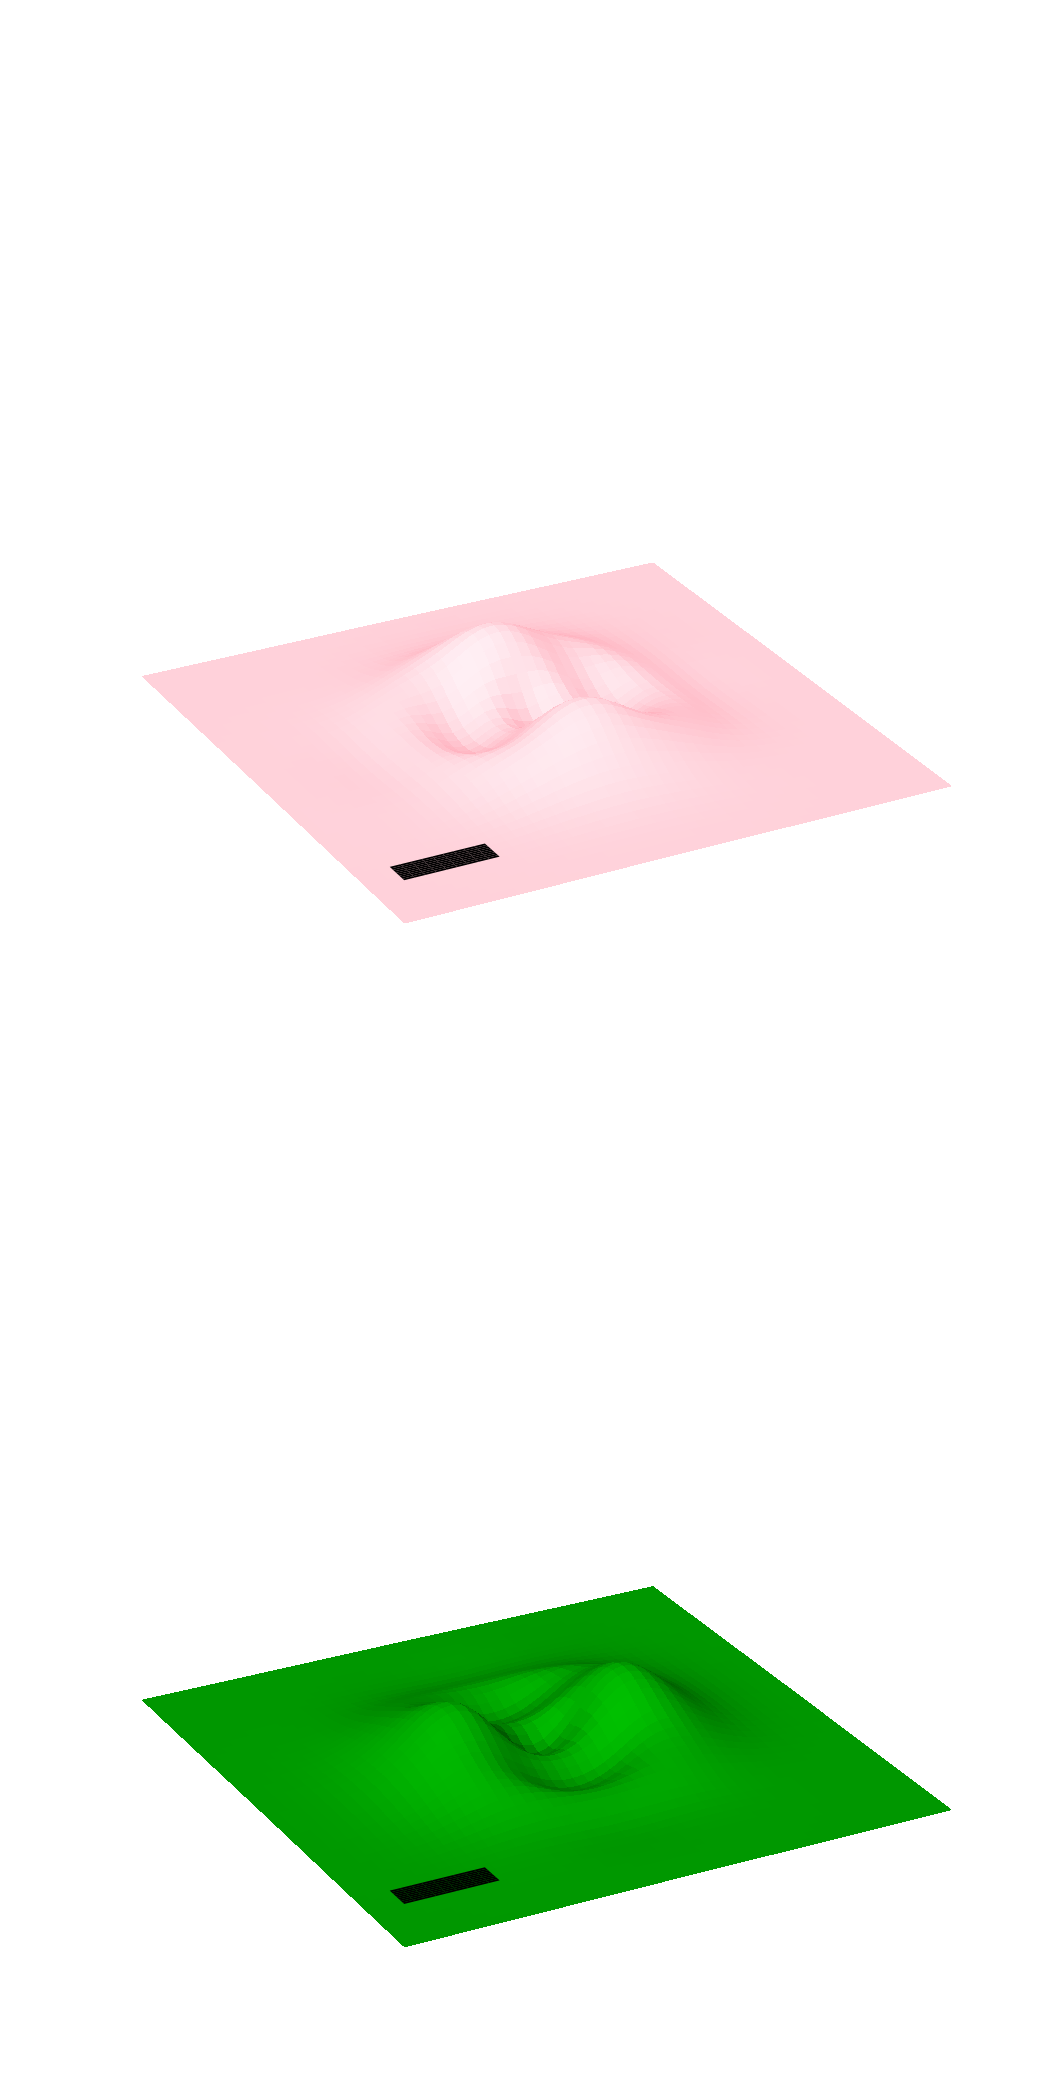

In [397]:
# # betalpha = np.array([[0, 0], [np.pi, 0], [np.pi/2, 0], [np.pi/2, np.pi]])
# sigma=1
# l = 3

# fig, ax = plt.subplots(2, 1, figsize=(3*1, 3*2), 
#                        subplot_kw={'projection': '3d'}, 
#                        constrained_layout=False, dpi=350)

# x = np.linspace(-3*W, 3*W, 200)
# y = np.linspace(-3*W, 3*W, 200)
# X, Y = np.meshgrid(x, y)
# phiR = np.arctan2(Y, X)
# R = np.sqrt(X**2+Y**2)

# def get_single_color_map(base_color):
#     # This creates a gradient from black to your base color to white
#     return LinearSegmentedColormap.from_list("custom", [base_color, base_color, base_color])
    
# for ex in range(2):
#     ax[ex].cla()
#     ax[ex].set_xlim(min(x), max(x))
#     ax[ex].set_ylim(min(y), max(y))
#     ax[ex].set_zlim(0, 1)
#     ax[ex].set_axis_off()
#     ax[ex].set_xticks([])
#     ax[ex].set_yticks([])
#     ax[ex].set_zticks([])
#     ax[ex].set_xlabel('x (um)')
#     ax[ex].set_ylabel('y (um)')
#     ax[ex].view_init(24, -118, 0) 
#     # ax[ex].view_init(0, -90, 0)
    
#     # Determine settings based on subplot index
#     if ex == 0:
#         mode_name, color_base = "upperbright", 'pink'
#     else:
#         mode_name, color_base = "lowerbright", 'green'
        
#     # if ex == 0:
#     #     mode_name, color_base = "upperbright", 'coral'
#     # else:
#     #     mode_name, color_base = "lowerbright", 'yellowgreen'
    
#     # if ex == 0:
#     #     mode_name, color_base = "upperbright", 'peru'
#     # else:
#     #     mode_name, color_base = "lowerbright", 'olivedrab'

#     # Calculate normalized data
#     data = np.abs(fs2(mode_name, sigma, l, R, phiR, 1))**2
#     maximum = np.max(np.abs(fs2("upperbright", sigma, 0, R, phiR, 1))**2)
#     z_norm = 0.35*(data / np.max(maximum))
#     print(maximum)

#     # Create the light source
#     ls = LightSource(azdeg=315, altdeg=65)
    
#     # Use a custom colormap based on your single color
#     cmap = get_single_color_map(color_base)
    
#     # Shade the surface (vert_exag controls how "sharp" the shadows look)
#     rgb = ls.shade(z_norm, cmap=cmap, vert_exag=50, blend_mode='soft')

#     # Plot using facecolors
#     ax[ex].plot_surface(X, Y, z_norm, 
#                         facecolors=rgb, 
#                         linewidth=0, 
#                         antialiased=False, 
#                         shade=False,
#                         zorder=2) # Manual shading is active

# n=np.linspace(min(x), min(x)+W, 10)
# m=np.linspace(min(y), min(y)+0.3*W, 10)
# n, m = np.meshgrid(n, m)
# ax[0].plot_surface(n, m, n*0+m*0+0.1, linewidth=0, color='k', zorder=0)
# ax[1].plot_surface(n, m, n*0+m*0+0.1, linewidth=0, color='k', zorder=0)
# # fig.subplots_adjust(left=0.075, bottom=0.1, right=0.9, top=0.9, wspace=0, hspace=0.06 )
# plt.tight_layout()
# plt.show()

In [409]:
A = 1

def fun1(k, phik, Re, phiRe, Rh, phiRh, Q, phiQ):
    Rh = Rh*np.cos()
    phiRh = 
    y = np.exp(complex(0,1)*k*np.cos(phik)*Re*np.cos(phiRe)) * np.exp(complex(0,1)*k*np.sin(phik)*Re*np.sin(phiRe))  *  np.exp(-complex(0,1)*k*np.cos(phik)*Rh*np.cos(phiRh)) * np.exp(-complex(0,1)*k*np.sin(phik)*Rh*np.sin(phiRh))
    return y

def fs1(k, Re, phiRe, Rh, phiRh, Q, phiQ):
    max = 2*np.pi
    min = 0
    h=(max-min)/50
    sim = 0
    phik = min+h/2
    while (phik<=max):
        sim += h/6 * (fun1(k, phik-h/2, Re, phiRe, Rh, phiRh, Q, phiQ)+4*fun1(k, phik, Re, phiRe, Rh, phiRh, Q, phiQ)+fun1(k, phik+h/2, Re, phiRe, Rh, phiRh, Q, phiQ))
        phik += h
    return sim
    
def fs2(Re, phiRe, Rh, phiRh, Q, phiQ):
    max = 1
    min = 0
    h=(max-min)/50
    sim = 0
    k   = min+h/2
    while (k<=max):
        sim += h/6 * (fs1(k-h/2, Re, phiRe, Rh, phiRh, Q, phiQ)+4*fs1(k, Re, phiRe, Rh, phiRh, Q, phiQ)+fs1(k+h/2, Re, phiRe, Rh, phiRh, Q, phiQ))
        k   += h
    return sim

KeyboardInterrupt: 

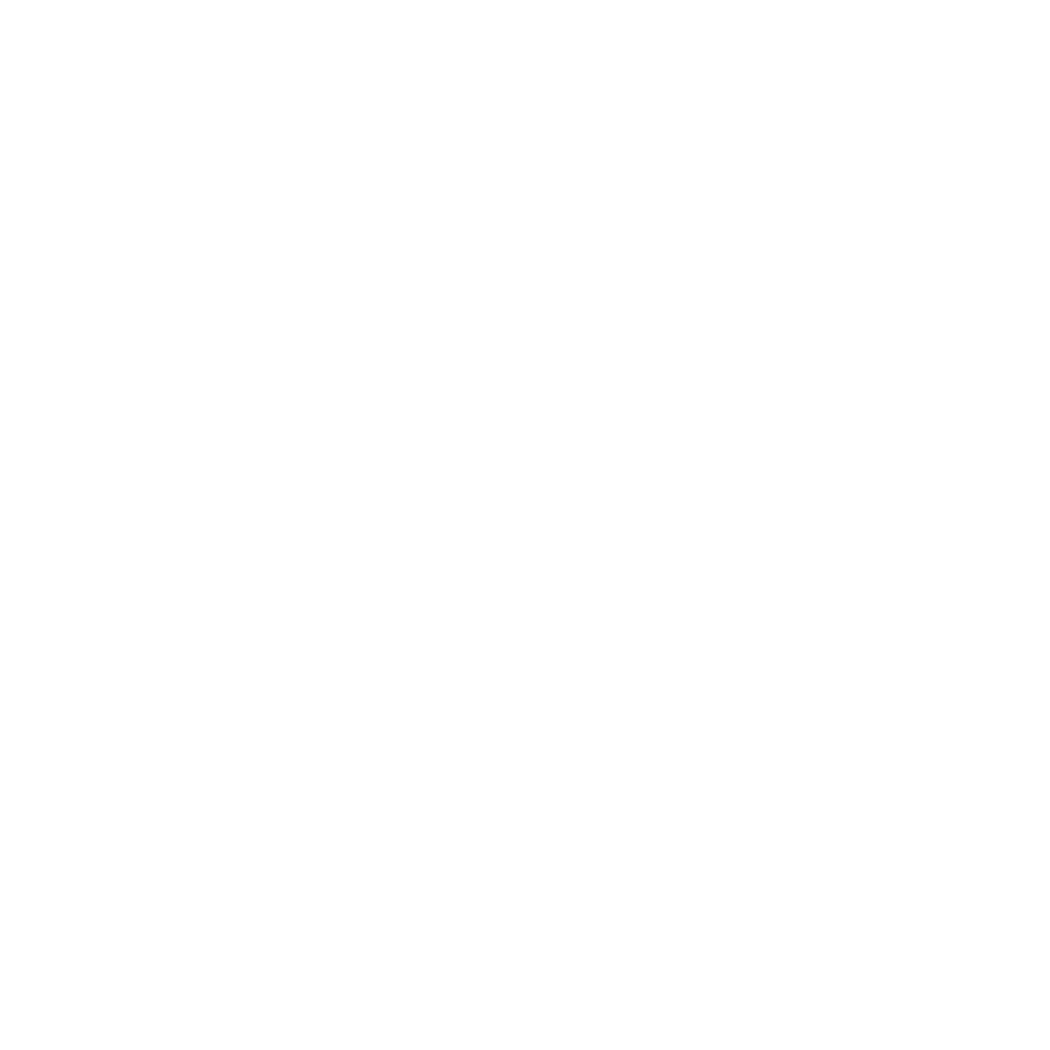

In [408]:
# betalpha = np.array([[0, 0], [np.pi, 0], [np.pi/2, 0], [np.pi/2, np.pi]])
fig, ax = plt.subplots(figsize=(3*1, 3*1), 
                       subplot_kw={'projection': '3d'}, 
                       constrained_layout=False, dpi=350)
Range = 6
x = np.linspace(-Range/2, Range/2, 400)
y = np.linspace(-Range/2, Range/2, 400)
X, Y = np.meshgrid(x, y)

phiRe = np.arctan2(Y, X)
Re = np.sqrt(X**2+Y**2)

phiRh = np.arctan2(Y, X)
Rh = np.sqrt(X**2*0+Y**2*0)

def get_single_color_map(base_color):
    # This creates a gradient from black to your base color to white
    return LinearSegmentedColormap.from_list("custom", [base_color, base_color, base_color])
    
ax.set_xlim(min(x), max(x))
ax.set_ylim(min(y), max(y))
ax.set_zlim(0, 1)
ax.set_axis_off()
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.view_init(24, -118, 0) 

# Calculate normalized data
data = np.abs(fs2(Re, phiRe, Rh, phiRh))**2
maximum = np.max(np.abs(fs2(Re, phiRe, Rh, phiRh))**2)
z_norm = 0.35*(data / np.max(maximum))
print(maximum)

# Create the light source
ls = LightSource(azdeg=315, altdeg=65)

# Use a custom colormap based on your single color
cmap = get_single_color_map('green')

# Shade the surface (vert_exag controls how "sharp" the shadows look)
rgb = ls.shade(z_norm, cmap=cmap, vert_exag=50, blend_mode='soft')

# Plot using facecolors
ax.plot_surface(X, Y, z_norm, 
                    facecolors=rgb, 
                    linewidth=0, 
                    antialiased=False, 
                    shade=False,
                    zorder=2) # Manual shading is active


# fig.subplots_adjust(left=0.075, bottom=0.1, right=0.9, top=0.9, wspace=0, hspace=0.06 )
plt.tight_layout()
plt.show()